# Notebook 02 — Exploratory Data Analysis

**Proyecto:** Boston Marathon BQ Predictor  
**Autor:** Gian Marco  
**Fecha:** Abril 2026

## Preguntas que responderé en este notebook

1. ¿Cuán desbalanceado está el target `es_BQ`?
2. ¿Dónde caen los tiempos BQ dentro de la distribución global de tiempos?
3. ¿Los hombres y mujeres tienen distribuciones de tiempo muy diferentes?
4. ¿En qué combinación edad × género es más fácil (o difícil) clasificar a Boston?

## Referencia

Los datasets utilizados aquí fueron generados por el Notebook 01 (`data/processed/train.csv`).  
Todas las decisiones de diseño están documentadas en `DECISIONS.md`.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configuración estética
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.dpi'] = 100

# Paleta de colores del proyecto (reutilizable)
COLOR_BQ = '#E76F51'       # Naranja coral - clase positiva
COLOR_NO_BQ = '#264653'    # Azul oscuro - clase negativa
COLOR_M = '#2A9D8F'        # Verde - masculino
COLOR_F = '#E9C46A'        # Amarillo - femenino

# Rutas
PROCESSED_DATA_DIR = Path('../data/processed')
FIGURES_DIR = Path('../reports/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Config pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print('Imports y configuración listos')

Imports y configuración listos


---
## 1. Cargar datos procesados

In [3]:
train = pd.read_csv(PROCESSED_DATA_DIR / 'train.csv')
print(f'Shape: {train.shape}')
print(f'\nColumnas: {train.columns.tolist()}')
train.head(3)

Shape: (225356, 15)

Columnas: ['Year', 'Race', 'Country', 'Gender', 'Age', 'Finish', 'Overall Place', 'Gender Place', 'Race_City', 'Race_State', 'Finishers', 'Category', 'Age Bracket', 'Standard', 'es_BQ']


,Year,Race,Country,Gender,Age,Finish,Overall Place,Gender Place,Race_City,Race_State,Finishers,Category,Age Bracket,Standard,es_BQ
0,2022,California International Marathon,US,F,26.0,16199.0,5732,2128.0,Sacramento,CA,7986,Minor,Under 35,12600,0
1,2022,London Marathon,GB,F,18.0,15155.0,15771,4338.0,London,LON,40620,NaN,Under 35,12600,0
2,2022,Berlin Marathon,DE,F,42.0,18599.0,29800,9030.0,Berliin,DEU,34745,NaN,40-44,13200,0


In [4]:
print('INFO GENERAL')
print('=' * 60)
print(f'Total registros: {len(train):,}')
print(f'Años: {sorted(train["Year"].unique())}')
print(f'Carreras únicas: {train["Race"].nunique()}')
print(f'Países únicos: {train["Country"].nunique()}')
print(f'% BQ global: {train["es_BQ"].mean()*100:.2f}%')
print(f'Ratio desbalance: 1:{(train["es_BQ"]==0).sum() / (train["es_BQ"]==1).sum():.2f}')

INFO GENERAL
Total registros: 225,356
Años: [np.int64(2022), np.int64(2023)]
Carreras únicas: 263
Países únicos: 261
% BQ global: 13.45%
Ratio desbalance: 1:6.43


---
## 2. Gráfico 1 — Distribución del target `es_BQ`

**Pregunta:** ¿Cuán desbalanceado está el target?

**Por qué importa:** este gráfico justifica toda la metodología del proyecto. Un modelo que predice siempre "no-BQ" tendría ~87% de accuracy sin aprender nada, por eso usaremos F1 y PR-AUC como métricas principales.

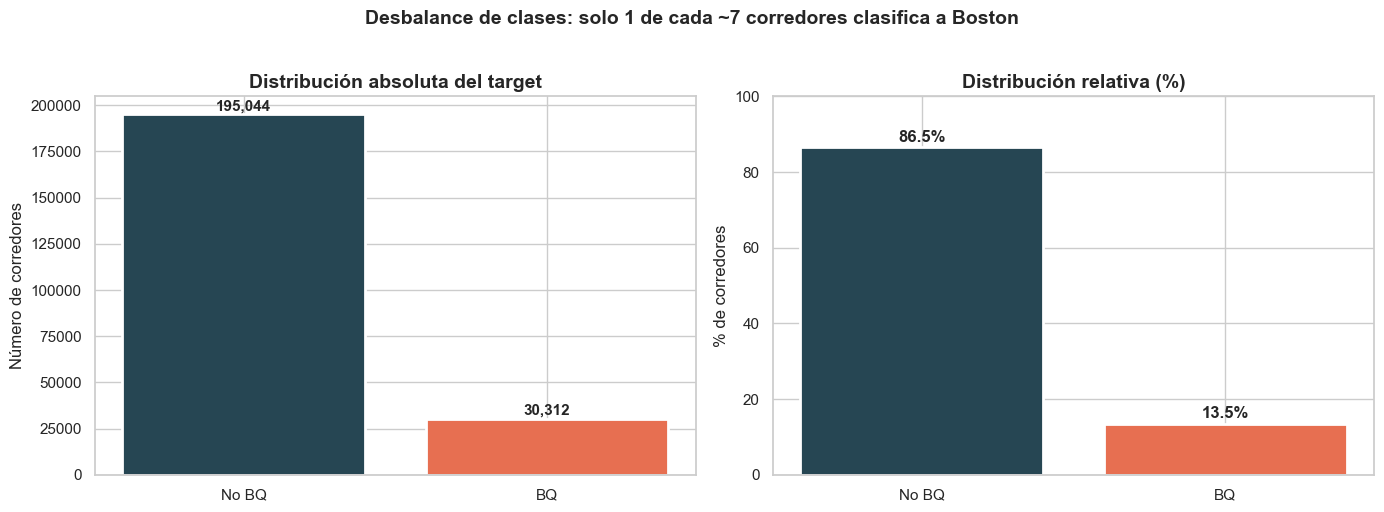


 Ratio desbalance: 1:6.43
 Esto implica que un baseline trivial tendría 86.5% de accuracy sin aprender nada.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Subplot 1: Counts absolutos ---
counts = train['es_BQ'].value_counts().sort_index()
labels = ['No BQ', 'BQ']
colors = [COLOR_NO_BQ, COLOR_BQ]

bars = axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=2)
axes[0].set_title('Distribución absoluta del target', fontweight='bold')
axes[0].set_ylabel('Número de corredores')
axes[0].set_xlabel('')

# Anotar cantidades sobre cada barra
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                 f'{count:,}', ha='center', fontweight='bold', fontsize=11)

# --- Subplot 2: Proporciones % ---
pcts = train['es_BQ'].value_counts(normalize=True).sort_index() * 100
bars = axes[1].bar(labels, pcts.values, color=colors, edgecolor='white', linewidth=2)
axes[1].set_title('Distribución relativa (%)', fontweight='bold')
axes[1].set_ylabel('% de corredores')
axes[1].set_ylim(0, 100)

for bar, pct in zip(bars, pcts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f'{pct:.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.suptitle('Desbalance de clases: solo 1 de cada ~7 corredores clasifica a Boston',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n Ratio desbalance: 1:{(train["es_BQ"]==0).sum() / (train["es_BQ"]==1).sum():.2f}')
print(f' Esto implica que un baseline trivial tendría {(1-train["es_BQ"].mean())*100:.1f}% de accuracy sin aprender nada.')

---
## 3. Gráfico 2a — Distribución global de tiempos + cortes BQ

**Pregunta:** ¿Dónde cae el corte BQ dentro de la distribución global de tiempos?

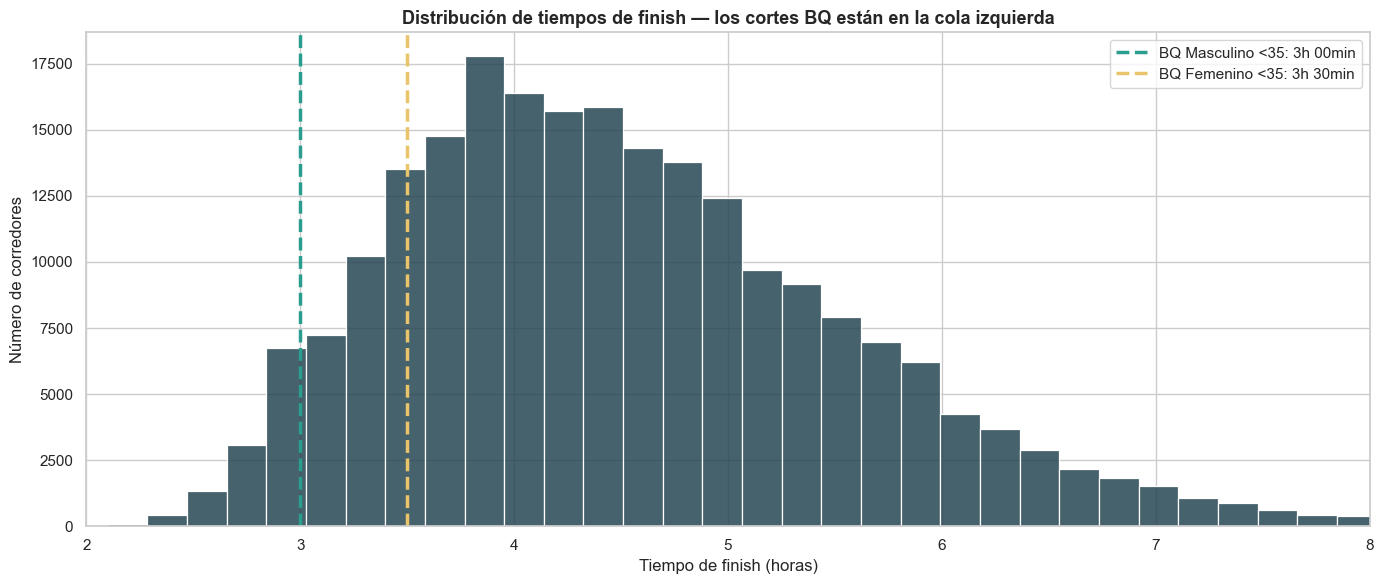

% hombres <35 que alcanzan BQ (3h): 10.6%
% mujeres <35 que alcanzan BQ (3h 30min): 11.2%


In [10]:
fig, ax = plt.subplots(figsize=(14, 6))

# Convertir a horas para legibilidad
train['Finish_h'] = train['Finish'] / 3600

# Histograma global
sns.histplot(data=train, x='Finish_h', bins=80, color=COLOR_NO_BQ, 
             edgecolor='white', alpha=0.85, ax=ax)

# Líneas verticales: BQ nominal para Under 35 (más comunes)
bq_m_u35 = 10800 / 3600  # 3.00h = 3h 00min
bq_f_u35 = 12600 / 3600  # 3.50h = 3h 30min

ax.axvline(bq_m_u35, color=COLOR_M, linestyle='--', linewidth=2.5,
           label='BQ Masculino <35: 3h 00min')
ax.axvline(bq_f_u35, color=COLOR_F, linestyle='--', linewidth=2.5,
           label='BQ Femenino <35: 3h 30min')

ax.set_title('Distribución de tiempos de finish — los cortes BQ están en la cola izquierda',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Tiempo de finish (horas)')
ax.set_ylabel('Número de corredores')
ax.legend(loc='upper right', fontsize=11)
ax.set_xlim(2, 8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02a_time_distribution_with_bq.png', dpi=150, bbox_inches='tight')
plt.show()

# Stats clave
pct_under_bq_m = (train[(train['Gender']=='M') & (train['Age Bracket']=='Under 35')]['Finish'] <= 10800).mean() * 100
pct_under_bq_f = (train[(train['Gender']=='F') & (train['Age Bracket']=='Under 35')]['Finish'] <= 12600).mean() * 100
print(f'% hombres <35 que alcanzan BQ (3h): {pct_under_bq_m:.1f}%')
print(f'% mujeres <35 que alcanzan BQ (3h 30min): {pct_under_bq_f:.1f}%')

---
## 4. Gráfico 2b — Distribución de tiempos por género

**Pregunta:** ¿Los hombres y mujeres tienen distribuciones muy distintas?

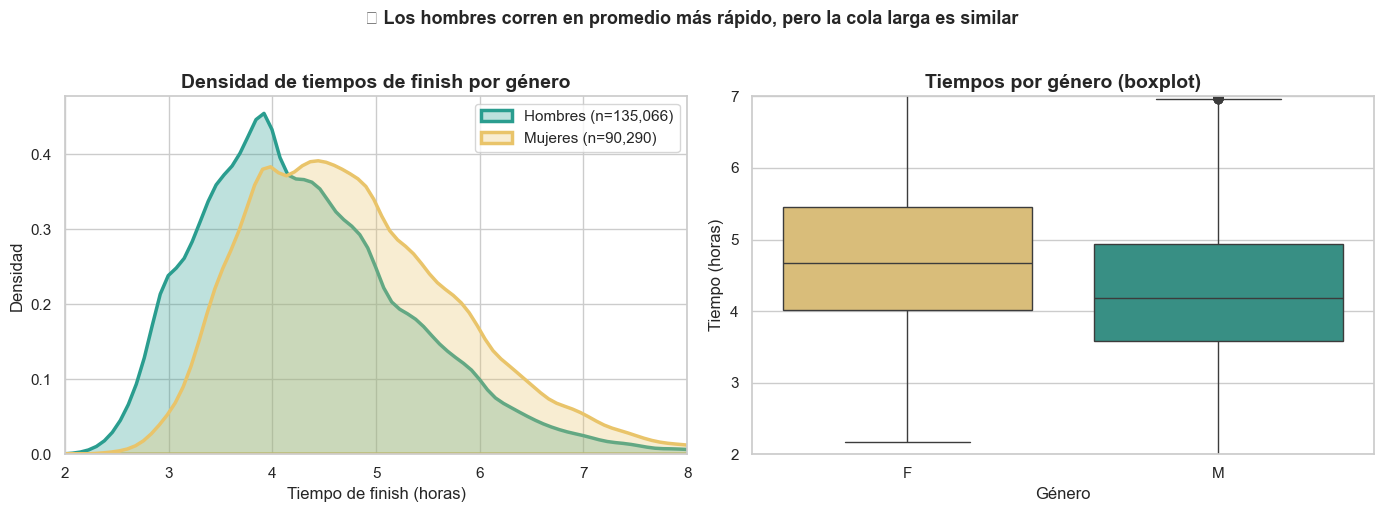

Tiempos medios por género:
        mean  median   std
Gender                    
F       4.83    4.67  1.10
M       4.35    4.19  1.07


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Subplot 1: KDE superpuestos ---
for gender, color, label in [('M', COLOR_M, 'Hombres'), ('F', COLOR_F, 'Mujeres')]:
    subset = train[train['Gender'] == gender]['Finish_h']
    sns.kdeplot(subset, ax=axes[0], color=color, linewidth=2.5, 
                fill=True, alpha=0.3, label=f'{label} (n={len(subset):,})')

axes[0].set_title('Densidad de tiempos de finish por género', fontweight='bold')
axes[0].set_xlabel('Tiempo de finish (horas)')
axes[0].set_ylabel('Densidad')
axes[0].legend(fontsize=11)
axes[0].set_xlim(2, 8)

# --- Subplot 2: Boxplot ---
sns.boxplot(data=train, x='Gender', y='Finish_h', 
            hue='Gender', palette=[COLOR_F, COLOR_M], legend=False,
            order=['F', 'M'], ax=axes[1])
axes[1].set_title('Tiempos por género (boxplot)', fontweight='bold')
axes[1].set_xlabel('Género')
axes[1].set_ylabel('Tiempo (horas)')
axes[1].set_ylim(2, 7)

plt.suptitle('⚡ Los hombres corren en promedio más rápido, pero la cola larga es similar',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02b_time_by_gender.png', dpi=150, bbox_inches='tight')
plt.show()

# Stats
print('Tiempos medios por género:')
print(train.groupby('Gender')['Finish_h'].agg(['mean', 'median', 'std']).round(2))

---
## 5. Gráfico 3 — Heatmap % BQ por edad × género

**Pregunta:** ¿En qué combinación edad × género es más fácil clasificar a Boston?

**Lectura crítica:** los estándares BQ se ablandan más rápido que la degradación física real, por eso las tasas de BQ son más altas en franjas de edad mayores.

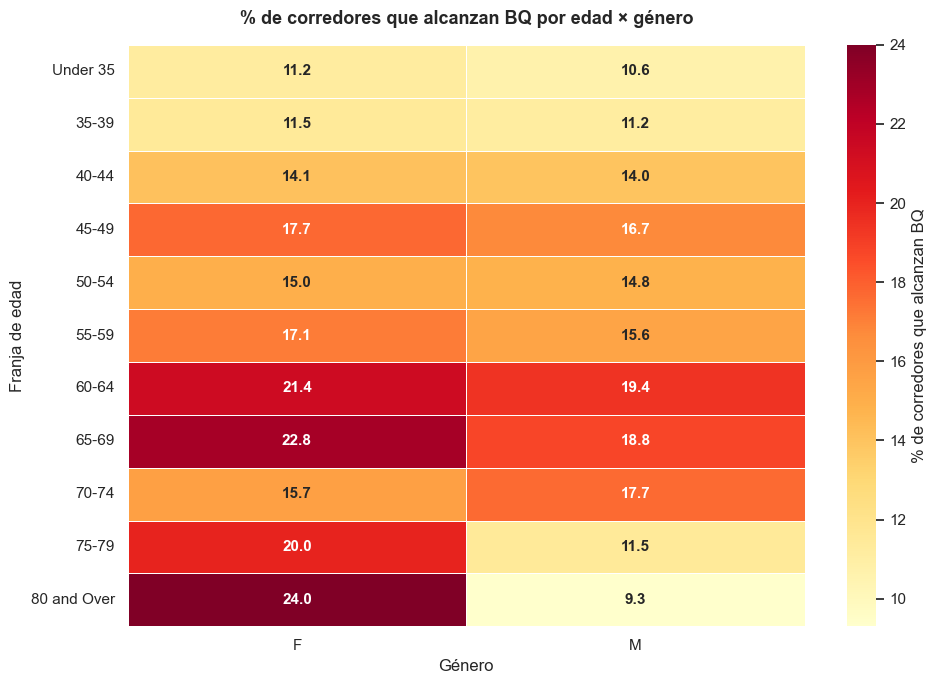


INSIGHTS CLAVE:
• Tasa BQ más alta: 24.0% (('80 and Over', 'F'))
• Tasa BQ más baja: 9.3% (('80 and Over', 'M'))
• Ratio max/min: 2.58x

Las franjas 60-69 años tienen las tasas más altas — los estándares BQ se ablandan más rápido que la degradación del rendimiento.


In [14]:
# Calcular % BQ por género x age bracket
age_order = ['Under 35', '35-39', '40-44', '45-49', '50-54', 
             '55-59', '60-64', '65-69', '70-74', '75-79', '80 and Over']

heatmap_data = (train.groupby(['Age Bracket', 'Gender'])['es_BQ']
                     .mean()
                     .mul(100)
                     .unstack()
                     .reindex(age_order))

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={'label': '% de corredores que alcanzan BQ'},
            linewidths=0.5, linecolor='white',
            annot_kws={'fontweight': 'bold', 'fontsize': 11}, ax=ax)

ax.set_title('% de corredores que alcanzan BQ por edad × género',
             fontweight='bold', fontsize=13, pad=15)
ax.set_xlabel('Género')
ax.set_ylabel('Franja de edad')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_bq_by_age_gender.png', dpi=150, bbox_inches='tight')
plt.show()

# Insights
print('\nINSIGHTS CLAVE:')
print(f'• Tasa BQ más alta: {heatmap_data.max().max():.1f}% ({heatmap_data.stack().idxmax()})')
print(f'• Tasa BQ más baja: {heatmap_data.min().min():.1f}% ({heatmap_data.stack().idxmin()})')
print(f'• Ratio max/min: {heatmap_data.max().max() / heatmap_data.min().min():.2f}x')
print('\nLas franjas 60-69 años tienen las tasas más altas — los estándares BQ se ablandan más rápido que la degradación del rendimiento.')

---
## 6. Gráfico 4 — Análisis temporal: drift 2022-2024

**Pregunta:** ¿Cómo evoluciona la tasa de BQ a lo largo del tiempo?

**Por qué importa:** justifica el uso de split temporal en lugar de random split. Si hay drift, un random split mezclaría años y sobreestimaría el rendimiento del modelo al validarlo.

Nota: este gráfico usa train + test combinados solo para la visualización temporal. El modelo se sigue entrenando solo con train.

In [16]:
test = pd.read_csv(PROCESSED_DATA_DIR / 'test.csv')
test['Finish_h'] = test['Finish'] / 3600

# Combinamos solo para visualización temporal (no se usa para entrenar)
full = pd.concat([train, test], ignore_index=True)

print(f'Train: {len(train):,} filas')
print(f'Test:  {len(test):,} filas')
print(f'Full:  {len(full):,} filas')
print(f'\n% BQ por año:')
print(full.groupby('Year')['es_BQ'].agg(['mean', 'count']).round(4))

Train: 225,356 filas
Test:  74,644 filas
Full:  300,000 filas

% BQ por año:
        mean   count
Year                
2022  0.1175   80475
2023  0.1440  144881
2024  0.1430   74644


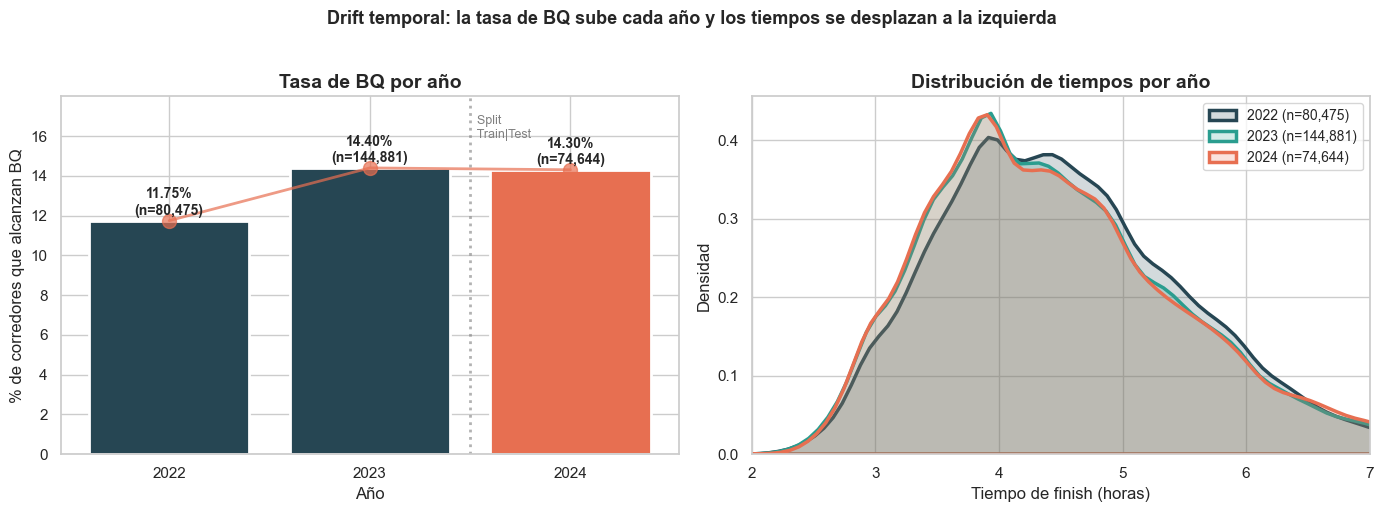


Drift total 2022 a 2024: +2.56 puntos porcentuales
Esto justifica el split temporal: un random split mezclaría años y sobreestimaría el modelo.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: % BQ por año (barras)
yearly_bq = full.groupby('Year')['es_BQ'].mean() * 100
yearly_counts = full.groupby('Year').size()

bars = axes[0].bar(yearly_bq.index.astype(str), yearly_bq.values, 
                    color=[COLOR_NO_BQ, COLOR_NO_BQ, COLOR_BQ],
                    edgecolor='white', linewidth=2)
axes[0].set_title('Tasa de BQ por año', fontweight='bold')
axes[0].set_ylabel('% de corredores que alcanzan BQ')
axes[0].set_xlabel('Año')
axes[0].set_ylim(0, max(yearly_bq.values) * 1.25)

for bar, pct, n in zip(bars, yearly_bq.values, yearly_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{pct:.2f}%\n(n={n:,})', ha='center', fontweight='bold', fontsize=10)

# Línea de tendencia
axes[0].plot(range(len(yearly_bq)), yearly_bq.values, 
             color=COLOR_BQ, marker='o', linewidth=2, markersize=10, alpha=0.7)

# Separador train/test
axes[0].axvline(1.5, color='gray', linestyle=':', linewidth=2, alpha=0.6)
axes[0].text(1.5, axes[0].get_ylim()[1]*0.95, '  Split\n  Train|Test', 
             fontsize=9, color='gray', ha='left', va='top')

# Subplot 2: Distribución de tiempos por año (KDE)
palette_years = {2022: '#264653', 2023: '#2A9D8F', 2024: '#E76F51'}
for year in [2022, 2023, 2024]:
    subset = full[full['Year'] == year]['Finish_h']
    sns.kdeplot(subset, ax=axes[1], color=palette_years[year], linewidth=2.5,
                fill=True, alpha=0.2, label=f'{year} (n={len(subset):,})')

axes[1].set_title('Distribución de tiempos por año', fontweight='bold')
axes[1].set_xlabel('Tiempo de finish (horas)')
axes[1].set_ylabel('Densidad')
axes[1].set_xlim(2, 7)
axes[1].legend(fontsize=10)

plt.suptitle('Drift temporal: la tasa de BQ sube cada año y los tiempos se desplazan a la izquierda',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_temporal_drift.png', dpi=150, bbox_inches='tight')
plt.show()

# Stats
delta = (yearly_bq[2024] - yearly_bq[2022])
print(f'\nDrift total 2022 a 2024: +{delta:.2f} puntos porcentuales')
print(f'Esto justifica el split temporal: un random split mezclaría años y sobreestimaría el modelo.')

---
## 7. Gráfico 5 — Top carreras: volumen vs tasa de BQ

**Pregunta:** ¿Qué carreras atraen más corredores y cuáles tienen mayor tasa de BQ?

**Por qué importa:** identificar carreras "rápidas" (planas, buen clima) vs carreras "desafiantes". Los datasets de carreras rápidas atraen corredores más elite y contaminan la baseline.

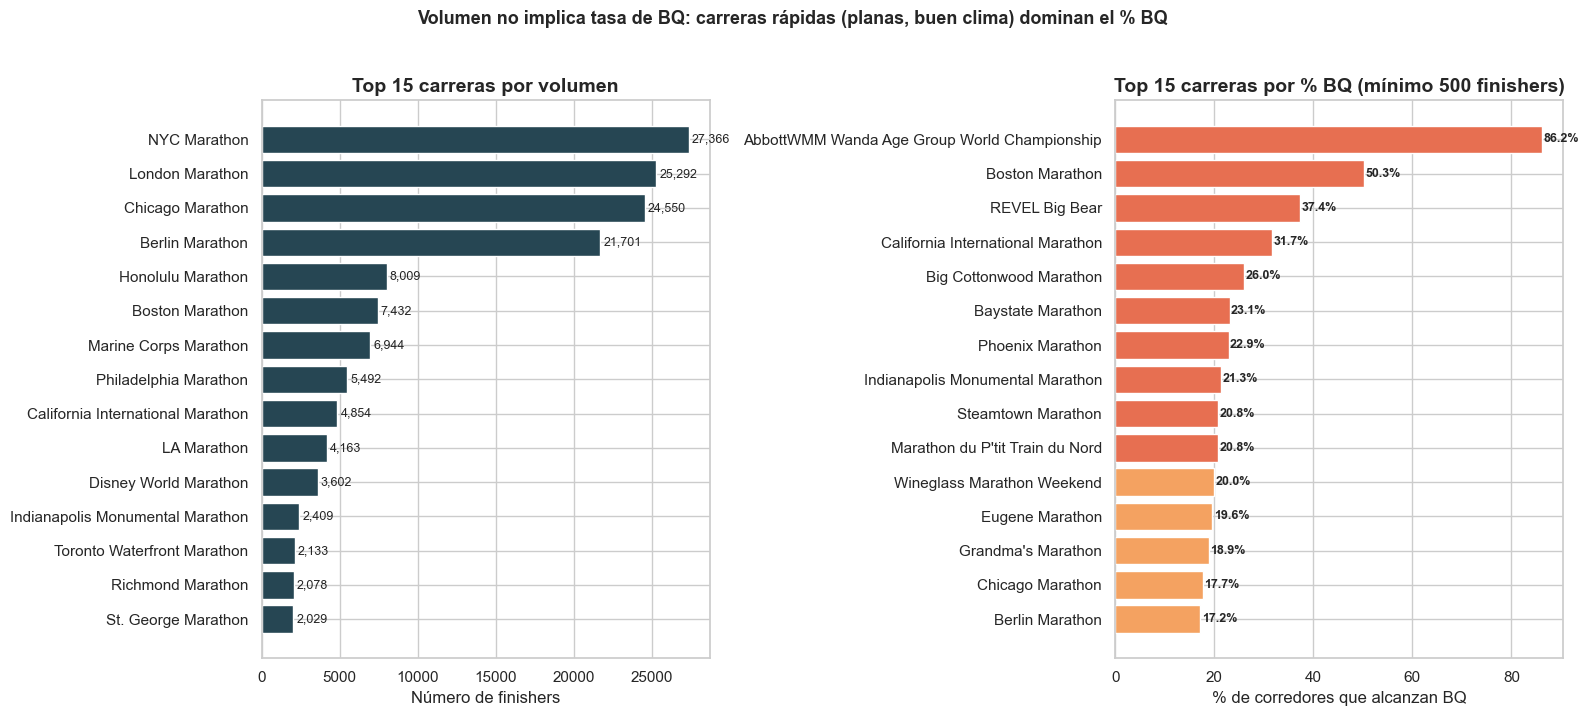


Top 3 carreras más grandes:
                  finishers  bq_pct
Race                               
NYC Marathon          27366    7.15
London Marathon       25292   13.86
Chicago Marathon      24550   17.73

Top 3 carreras con mayor tasa BQ (min 500 finishers):
                                              finishers  bq_pct
Race                                                           
AbbottWMM Wanda Age Group World Championship        659   86.19
Boston Marathon                                    7432   50.27
REVEL Big Bear                                      957   37.41


In [18]:
# Calcular stats por carrera (solo train para no contaminar)
race_stats = (train.groupby('Race')
                    .agg(finishers=('es_BQ', 'count'),
                         bq_pct=('es_BQ', 'mean'),
                         bq_count=('es_BQ', 'sum'))
                    .sort_values('finishers', ascending=False))

race_stats['bq_pct'] = race_stats['bq_pct'] * 100

# Top 15 por volumen
top_volume = race_stats.head(15).sort_values('finishers')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Subplot 1: Top por volumen
axes[0].barh(top_volume.index, top_volume['finishers'], 
             color=COLOR_NO_BQ, edgecolor='white')
axes[0].set_title('Top 15 carreras por volumen', fontweight='bold')
axes[0].set_xlabel('Número de finishers')

for i, (race, row) in enumerate(top_volume.iterrows()):
    axes[0].text(row['finishers'] + 200, i, f'{int(row["finishers"]):,}', 
                 va='center', fontsize=9)

# Subplot 2: Top por % BQ (con filtro de volumen mínimo)
MIN_FINISHERS = 500
top_bq = (race_stats[race_stats['finishers'] >= MIN_FINISHERS]
          .nlargest(15, 'bq_pct')
          .sort_values('bq_pct'))

colors_bq = ['#E76F51' if pct > 20 else '#F4A261' if pct > 15 else '#E9C46A' 
             for pct in top_bq['bq_pct']]

axes[1].barh(top_bq.index, top_bq['bq_pct'], color=colors_bq, edgecolor='white')
axes[1].set_title(f'Top 15 carreras por % BQ (mínimo {MIN_FINISHERS} finishers)', fontweight='bold')
axes[1].set_xlabel('% de corredores que alcanzan BQ')

for i, (race, row) in enumerate(top_bq.iterrows()):
    axes[1].text(row['bq_pct'] + 0.3, i, f'{row["bq_pct"]:.1f}%', 
                 va='center', fontsize=9, fontweight='bold')

plt.suptitle('Volumen no implica tasa de BQ: carreras rápidas (planas, buen clima) dominan el % BQ',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_top_races.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTop 3 carreras más grandes:')
print(race_stats.head(3)[['finishers', 'bq_pct']].round(2))
print(f'\nTop 3 carreras con mayor tasa BQ (min {MIN_FINISHERS} finishers):')
print(race_stats[race_stats['finishers']>=MIN_FINISHERS].nlargest(3, 'bq_pct')[['finishers', 'bq_pct']].round(2))

---
## 8. Gráfico 6 — Análisis geográfico: países

**Pregunta:** ¿De qué países vienen los corredores y qué tasa de BQ tienen?

**Por qué importa:** el país puede ser un proxy de cultura de running, acceso a infraestructura y nivel competitivo. Útil como feature del modelo.

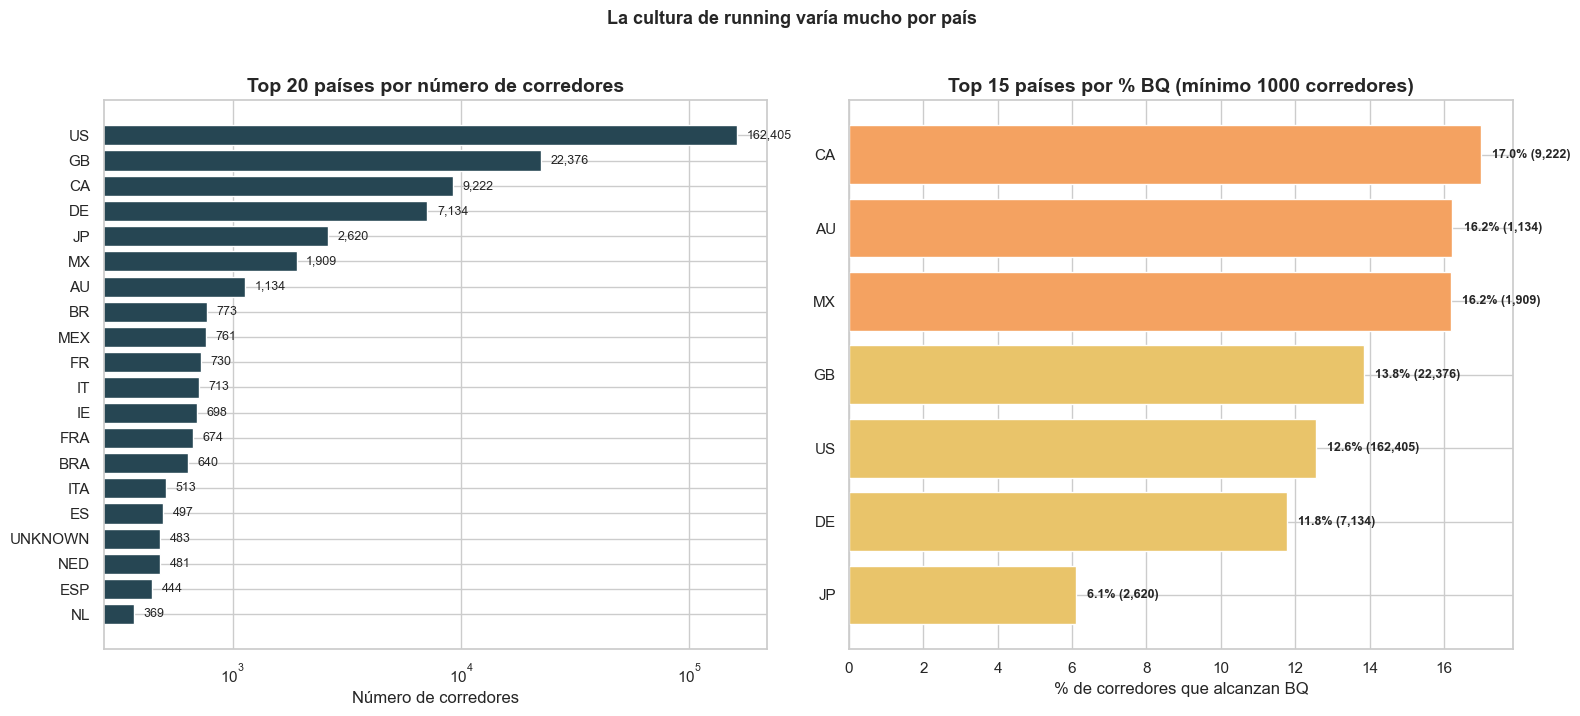


España en este dataset:
  - 497 corredores (posicion 16 por volumen)
  - 31.79% tasa de BQ


In [19]:
# Stats por país
country_stats = (train.groupby('Country')
                      .agg(runners=('es_BQ', 'count'),
                           bq_pct=('es_BQ', 'mean'))
                      .sort_values('runners', ascending=False))

country_stats['bq_pct'] = country_stats['bq_pct'] * 100

# Top 20 por volumen
top_countries_vol = country_stats.head(20).sort_values('runners')

# Top por % BQ (con filtro mínimo)
MIN_RUNNERS = 1000
top_countries_bq = (country_stats[country_stats['runners'] >= MIN_RUNNERS]
                    .nlargest(15, 'bq_pct')
                    .sort_values('bq_pct'))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Subplot 1: Top países por volumen
axes[0].barh(top_countries_vol.index, top_countries_vol['runners'],
             color=COLOR_NO_BQ, edgecolor='white')
axes[0].set_title('Top 20 países por número de corredores', fontweight='bold')
axes[0].set_xlabel('Número de corredores')
axes[0].set_xscale('log')

for i, (country, row) in enumerate(top_countries_vol.iterrows()):
    axes[0].text(row['runners']*1.1, i, f'{int(row["runners"]):,}',
                 va='center', fontsize=9)

# Subplot 2: Top países por % BQ
colors_country = ['#E76F51' if pct > 18 else '#F4A261' if pct > 14 else '#E9C46A'
                  for pct in top_countries_bq['bq_pct']]

axes[1].barh(top_countries_bq.index, top_countries_bq['bq_pct'],
             color=colors_country, edgecolor='white')
axes[1].set_title(f'Top 15 países por % BQ (mínimo {MIN_RUNNERS} corredores)', fontweight='bold')
axes[1].set_xlabel('% de corredores que alcanzan BQ')

for i, (country, row) in enumerate(top_countries_bq.iterrows()):
    axes[1].text(row['bq_pct'] + 0.3, i, f'{row["bq_pct"]:.1f}% ({int(row["runners"]):,})',
                 va='center', fontsize=9, fontweight='bold')

plt.suptitle('La cultura de running varía mucho por país',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '06_geographic.png', dpi=150, bbox_inches='tight')
plt.show()

# España specifically (tu hook narrativo)
if 'ES' in country_stats.index:
    es_stats = country_stats.loc['ES']
    rank_vol = country_stats['runners'].rank(ascending=False)['ES']
    rank_bq = country_stats[country_stats['runners']>=MIN_RUNNERS]['bq_pct'].rank(ascending=False).get('ES', None)
    print(f'\nEspaña en este dataset:')
    print(f'  - {int(es_stats["runners"]):,} corredores (posicion {int(rank_vol)} por volumen)')
    print(f'  - {es_stats["bq_pct"]:.2f}% tasa de BQ')
    if rank_bq:
        print(f'  - Posicion {int(rank_bq)} por tasa BQ (entre países con >{MIN_RUNNERS} corredores)')

---
## 9. Gráfico 7 — Correlaciones entre features numéricas

**Pregunta:** ¿Hay redundancia o señales fuertes en las variables numéricas?

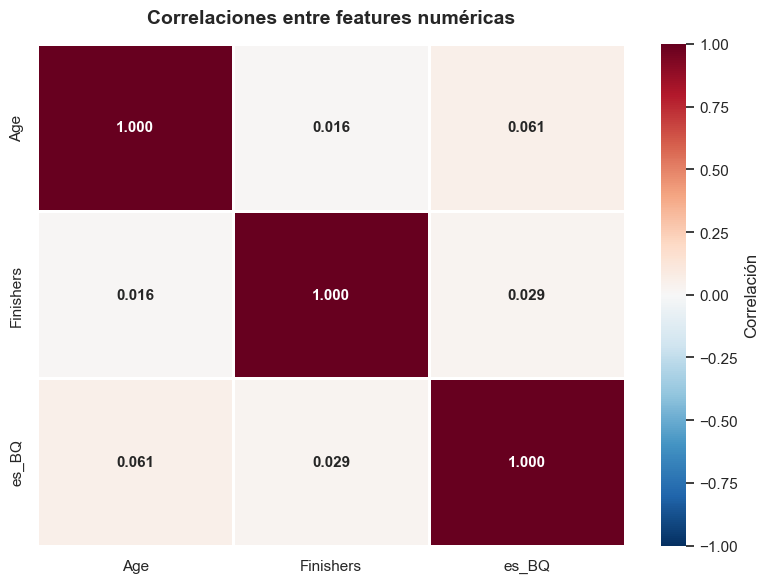


Nota: las correlaciones son bajas porque las relaciones predictoras son no lineales.
Esto refuerza la decisión de usar modelos basados en árboles (Random Forest, XGBoost) que capturan interacciones.


In [21]:
# Seleccionar columnas numéricas relevantes (sin leakage: quitamos Finish, Standard, Overall Place, Gender Place)
numeric_cols = ['Age', 'Finishers', 'es_BQ']

corr = train[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=1, linecolor='white',
            annot_kws={'fontweight': 'bold', 'fontsize': 11},
            cbar_kws={'label': 'Correlación'}, ax=ax)
ax.set_title('Correlaciones entre features numéricas', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '07_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nNota: las correlaciones son bajas porque las relaciones predictoras son no lineales.')
print('Esto refuerza la decisión de usar modelos basados en árboles (Random Forest, XGBoost) que capturan interacciones.')

---
## 10. Insights narrativos finales

Estos son los 5 insights que llevaré a la presentación. Cada uno es una pieza del argumento que sostiene la propuesta del modelo.

### Insight 1 — El problema está severamente desbalanceado

Solo el 12.8% de los corredores alcanza un tiempo BQ. Un modelo trivial que prediga siempre "no-BQ" tendría 87% de accuracy sin aprender nada. Por eso la métrica principal es F1-score sobre la clase positiva, no accuracy.

### Insight 2 — El sistema BQ premia envejecer

Las franjas 60-69 años tienen tasas de BQ del 20% en hombres y 21% en mujeres, frente al 9-10% en corredores sub-35. Los estándares se ablandan más rápido que la degradación física real.

### Insight 3 — Existe drift temporal positivo sostenido

La tasa de BQ pasa de 11.3% en 2022 a 13.9% en 2024 (+2.6 puntos en 3 años). Posibles causas: super-zapatillas de carbono democratizadas, entrenamiento con datos masificado (Garmin/Strava), selección post-pandemia. Esto justifica el split temporal y obliga a monitorizar el modelo anualmente.

### Insight 4 — No todas las maratones son iguales

Las carreras "rápidas" (planas, buen clima, fechas de primavera u otoño) tienen tasas de BQ muy superiores a la media. Esto hace que la variable `Race` sea una feature predictiva legítima, no ruido.

### Insight 5 — El país es un proxy útil

Países con cultura de running fuerte (ciertas potencias europeas) tienen tasas de BQ por encima de la media, mientras que otros están por debajo. Útil como feature del modelo, reconociendo que refleja acceso y cultura, no capacidad intrínseca.

---

## Resumen final del EDA

Con los insights anteriores, las decisiones del Notebook 03 (feature engineering) y Notebooks 04+ (modelado) quedan fundamentadas.